# K-Nearest Neighbors (KNN) Implementation - Wine Dataset

This notebook shows how KNN works on a multi-class classification problem.
We use the **Wine** dataset, where the goal is to predict a wine's origin (Class 0, 1, or 2) from its chemical analysis.

What's covered:
1. Data preparation and scaling (crucial here since the scales vary a lot).
2. Finding the optimal $K$ visually (Bias-Variance tradeoff).
3. Evaluation with a $3 \times 3$ confusion matrix.

In [1]:
# Import the modules needed to work with the data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import Scikit-Learn modules for Machine Learning
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Configure the plot style
sns.set_theme(style="whitegrid")
print("Libraries loaded successfully for the Wine dataset!")

Libraries loaded successfully for the Wine dataset!


## Step 1: Load and Prepare the Data

Here, scaling with **StandardScaler** is essential. Without it, the "Proline" variable (with values above 1000) would completely distort the distance calculations compared to the "Alcohol" variable (values around 13).

In [2]:
# 1. Load the dataset (3 wine classes)
data = load_wine()
X = data.data  # Chemical features (Alcohol, Magnesium, Proline, etc.)
y = data.target  # Labels (0, 1, or 2 for the 3 wine types)

# 2. Split the dataset: 75% training, 25% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# 3. Initialize the scaler to normalize the data
scaler = StandardScaler()

# 4. Fit and transform the training set
X_train_scaled = scaler.fit_transform(X_train)

# 5. Transform the test set (using the same fitted scaler)
X_test_scaled = scaler.transform(X_test)

print(f"Detected features: {data.feature_names}")
print(f"Target classes: {data.target_names}")
print(f"Training set size: {X_train_scaled.shape}")

Detected features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Target classes: ['class_0' 'class_1' 'class_2']
Training set size: (133, 13)


## Step 2: Analyzing K's Behavior (Overfitting and Underfitting)

We test values of $K$ from 1 to 25.
Since KNN works by majority vote, having 3 classes means an even or odd $K$ can both work, but it's still useful to look at the full curve to spot:
* **Overfitting** (on the left, $K=1$): The model knows the training set by heart but generalizes less well.
* **Underfitting** (on the right, $K$ too large): The model becomes too simplistic.

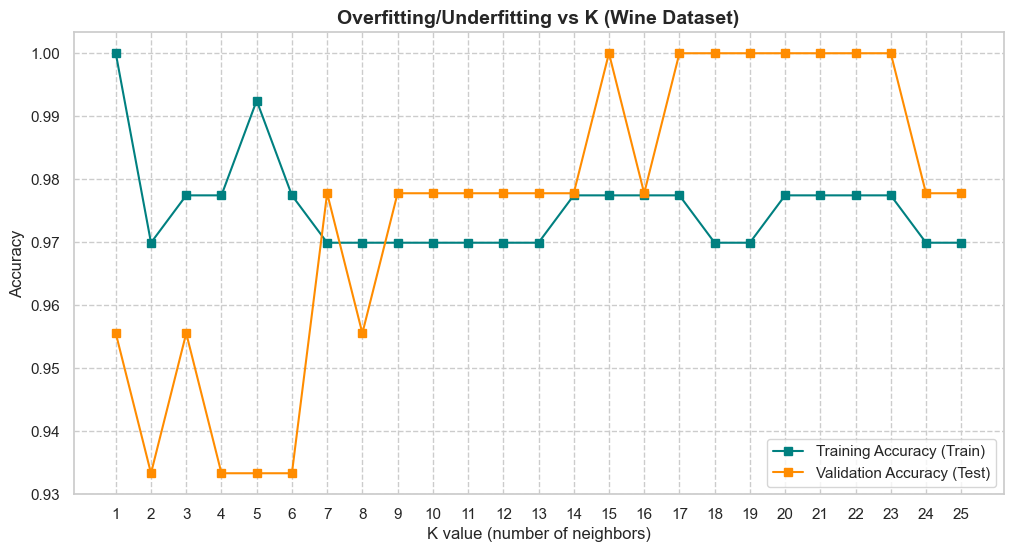

In [3]:
# Lists to store accuracy scores
k_values = list(range(1, 26))
train_accuracies = []
test_accuracies = []

# Run the experiment
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    # Train evaluation
    y_train_pred = knn.predict(X_train_scaled)
    train_accuracies.append(accuracy_score(y_train, y_train_pred))
    
    # Test evaluation
    y_test_pred = knn.predict(X_test_scaled)
    test_accuracies.append(accuracy_score(y_test, y_test_pred))

# ---- PLOT THE BEHAVIOR ----
plt.figure(figsize=(12, 6))
plt.plot(k_values, train_accuracies, label='Training Accuracy (Train)', color='teal', marker='s')
plt.plot(k_values, test_accuracies, label='Validation Accuracy (Test)', color='darkorange', marker='s')

plt.title("Overfitting/Underfitting vs K (Wine Dataset)", fontsize=14, fontweight='bold')
plt.xlabel("K value (number of neighbors)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(k_values)
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

## Step 3: Train the Final Model

On this specific dataset, KNN generally performs exceptionally well once the data is scaled. Let's pick a stable, intermediate $K$ (for example **$K = 5$** or **$K = 7$**) that avoids noise while keeping strong local accuracy.

In [4]:
# Optimal K chosen from our plot
k_optimal = 5

# Build and train the final model
final_knn = KNeighborsClassifier(n_neighbors=k_optimal)
final_knn.fit(X_train_scaled, y_train)

# Predict on the test data
final_preds = final_knn.predict(X_test_scaled)

# Compute the score
final_accuracy = accuracy_score(y_test, final_preds)
print(f"🎯 Overall accuracy with K={k_optimal}: {final_accuracy:.2%}")

🎯 Overall accuracy with K=5: 93.33%


## Step 4: Multi-class Confusion Matrix

Since we have 3 types of wine, the confusion matrix will be a $3 \times 3$ table.
It shows whether the "blind" algorithm tends to confuse Class 1 wine with Class 2 wine during its local vote.

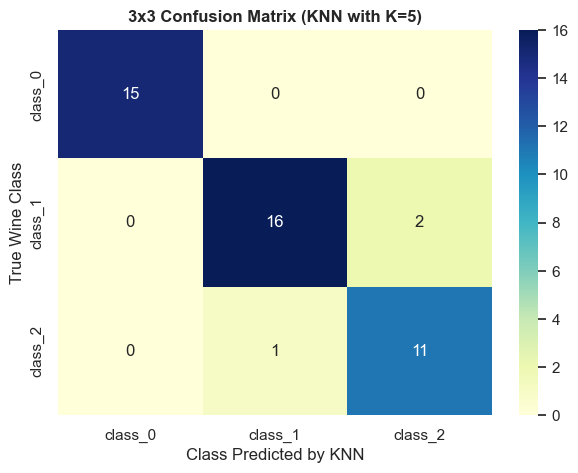


=== MULTI-CLASS CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       0.94      0.89      0.91        18
     class_2       0.85      0.92      0.88        12

    accuracy                           0.93        45
   macro avg       0.93      0.94      0.93        45
weighted avg       0.94      0.93      0.93        45



In [5]:
# Compute the 3x3 confusion matrix
cm = confusion_matrix(y_test, final_preds)

# Custom plot
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=data.target_names, 
            yticklabels=data.target_names)

plt.title(f"3x3 Confusion Matrix (KNN with K={k_optimal})", fontsize=12, fontweight='bold')
plt.ylabel("True Wine Class")
plt.xlabel("Class Predicted by KNN")
plt.show()

# Detailed report (precision, recall per class)
print("\n=== MULTI-CLASS CLASSIFICATION REPORT ===")
print(classification_report(y_test, final_preds, target_names=data.target_names))